# Forecasting one product with Prophet

This notebook forecasts daily sales for a single product (**store 1, item 1**) using
[Prophet](https://facebook.github.io/prophet/), a forecasting library from Meta.
We hide the last 8 weeks of real sales from the model, ask it to predict them,
and then measure how close it got.

In [12]:
# Install Prophet into this notebook's environment (only needed once)
%pip install prophet

Note: you may need to restart the kernel to use updated packages.


## Step 1: Import the libraries

- **pandas** loads and reshapes the data.
- **Prophet** is the forecasting model. It learns the overall trend plus repeating
  weekly and yearly patterns, then continues them into the future.
- **matplotlib** draws the comparison chart at the end.

In [13]:
import logging

import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet

# Prophet uses a helper library (cmdstanpy) that prints technical progress messages
# while it trains. Turning its logger off keeps the output readable.
logging.getLogger("cmdstanpy").disabled = True

# Load the full dataset; parse_dates turns the "date" column into real dates
sales_df = pd.read_csv("../data/train.csv", parse_dates=["date"])
print("Full dataset shape:", sales_df.shape)

Full dataset shape: (913000, 4)


## Step 2: Keep only one product

The dataset has 500 store-item combinations. To start simple, we forecast just one:
**store 1, item 1**. Each row is then one day of sales for that product.

In [14]:
# A condition like (sales_df["store"] == 1) gives True/False for every row.
# Combining two conditions with & keeps only rows where BOTH are True.
product_df = sales_df[(sales_df["store"] == 1) & (sales_df["item"] == 1)]

print("Rows for store 1, item 1:", len(product_df))
print("Date range:", product_df["date"].min().date(), "to", product_df["date"].max().date())
product_df.head()

Rows for store 1, item 1: 1826
Date range: 2013-01-01 to 2017-12-31


,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


## Step 3: Rename the columns for Prophet

Prophet expects exactly two columns with fixed names:
- **`ds`** (datestamp): the date
- **`y`**: the value we want to forecast (here, daily sales)

In [15]:
# .rename(columns={old: new}) renames columns.
# We then keep only the two columns Prophet needs, in date order.
# .reset_index(drop=True) renumbers the rows 0, 1, 2, ... (the old row numbers aren't needed).
prophet_df = (
    product_df
    .rename(columns={"date": "ds", "sales": "y"})[["ds", "y"]]
    .sort_values("ds")
    .reset_index(drop=True)
)
prophet_df.head()

,ds,y
0,2013-01-01,13
1,2013-01-02,11
2,2013-01-03,14
3,2013-01-04,13
4,2013-01-05,10


## Step 4: Split into training and test sets by date

We train the model on the past and test it on the most recent **8 weeks**, which it never sees.
This mimics real life: you only know the past and want to predict the future.

We must **not** split randomly. A random split would put future days into training,
letting the model "peek" at the future and making its accuracy look better than it really is.

In [16]:
# Find the last date, then go back 8 weeks to find where the test period starts.
# pd.Timedelta represents a length of time (here, 8 weeks = 56 days).
last_date = prophet_df["ds"].max()
test_start_date = last_date - pd.Timedelta(weeks=8) + pd.Timedelta(days=1)

# Everything before the test start date is training; the rest is test
train_df = prophet_df[prophet_df["ds"] < test_start_date]
test_df = prophet_df[prophet_df["ds"] >= test_start_date]

print(f"Training set: {len(train_df)} days ({train_df['ds'].min().date()} to {train_df['ds'].max().date()})")
print(f"Test set:     {len(test_df)} days ({test_df['ds'].min().date()} to {test_df['ds'].max().date()})")

Training set: 1770 days (2013-01-01 to 2017-11-05)
Test set:     56 days (2017-11-06 to 2017-12-31)


## Step 5: Train the Prophet model

The model learns from the training set only. We switch on two repeating patterns:
- **Weekly seasonality**: some weekdays sell more than others (we saw weekends are busier).
- **Yearly seasonality**: some months sell more than others (we saw summer peaks).

In [17]:
# Create an (untrained) Prophet model and tell it which patterns to look for
model = Prophet(yearly_seasonality=True, weekly_seasonality=True)

# .fit() trains the model: it studies the training data to learn the trend and patterns
model.fit(train_df)
print("Model trained.")

Model trained.


## Step 6: Predict the test period

We give the model the test dates (only the dates, not the real sales)
and ask it to predict sales for each one.

In [18]:
# .predict() needs a DataFrame with a "ds" column holding the dates to forecast.
# test_df[["ds"]] (double brackets) selects just that column as a DataFrame.
forecast_df = model.predict(test_df[["ds"]])

# The result has many columns; the most useful are:
#   yhat        - the predicted sales ("y-hat" is the standard name for a prediction)
#   yhat_lower  - a low estimate
#   yhat_upper  - a high estimate
forecast_df[["ds", "yhat", "yhat_lower", "yhat_upper"]].head()

,ds,yhat,yhat_lower,yhat_upper
0,2017-11-06,18.974999,13.263163,25.102419
1,2017-11-07,21.818587,15.892943,27.648896
2,2017-11-08,22.580482,16.811028,28.510690
3,2017-11-09,23.450252,17.707258,29.010732
4,2017-11-10,25.245853,19.634588,30.791335


## Step 7: Measure the accuracy

We compare each predicted value with the real sales for that day using two common metrics:
- **MAPE** (Mean Absolute Percentage Error): the average size of the error as a percentage
  of the real value. Easy to explain ("off by 20% on average"). Lower is better.
- **RMSE** (Root Mean Squared Error): the typical size of the error in units sold.
  Big misses count extra, so it warns you about occasional large errors. Lower is better.

In [19]:
# .to_numpy() pulls out the plain numbers, so both lists line up day by day
actual_sales = test_df["y"].to_numpy()
predicted_sales = forecast_df["yhat"].to_numpy()

# The error for each day is: prediction minus reality
errors = predicted_sales - actual_sales

# MAPE: for each day, divide the error size by the real sales to get a percentage,
# then average those percentages. .abs() ignores whether we were too high or too low.
# (A day with 0 real sales would divide by zero, so we leave such days out.)
nonzero_days = actual_sales != 0
mape = (abs(errors[nonzero_days]) / actual_sales[nonzero_days]).mean() * 100

# RMSE: square each error (making big errors much bigger), average them,
# then take the square root to get back to "units sold"
rmse = ((errors ** 2).mean()) ** 0.5

print(f"MAPE: {mape:.1f}%  -> on average, the forecast missed by this percentage of real sales")
print(f"RMSE: {rmse:.2f} units  -> the typical size of a daily miss, in units sold")
print(f"(For scale: average real daily sales in the test period = {actual_sales.mean():.1f} units)")

MAPE: 24.7%  -> on average, the forecast missed by this percentage of real sales
RMSE: 4.58 units  -> the typical size of a daily miss, in units sold
(For scale: average real daily sales in the test period = 19.4 units)


## Step 8: Compare the forecast to reality on a chart

The top chart shows the full history, so you can see where the test period sits.
The test period is short compared to 5 years of history, so the bottom chart zooms in on
the last few months to compare the actual and predicted lines day by day.

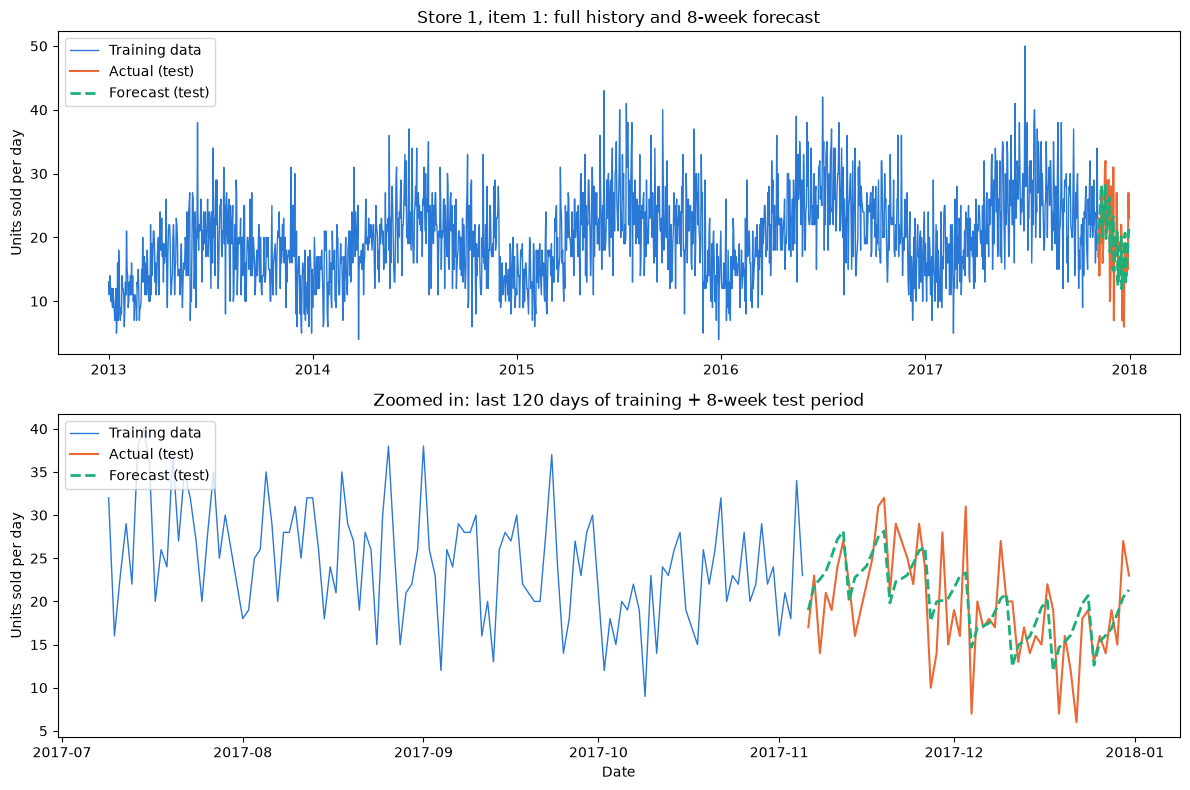

In [20]:
# plt.subplots(2, 1) creates two charts stacked on top of each other
fig, (full_ax, zoom_ax) = plt.subplots(2, 1, figsize=(12, 8))

# Colours: training in blue, actual test sales in orange, forecast in green (dashed)
TRAIN_COLOR, ACTUAL_COLOR, FORECAST_COLOR = "#2a78d6", "#eb6834", "#1baf7a"

# Only show the last 120 days of training data in the zoomed chart
zoom_train_df = train_df[train_df["ds"] >= test_start_date - pd.Timedelta(days=120)]

for ax, train_part in [(full_ax, train_df), (zoom_ax, zoom_train_df)]:
    ax.plot(train_part["ds"], train_part["y"], color=TRAIN_COLOR, linewidth=1, label="Training data")
    ax.plot(test_df["ds"], test_df["y"], color=ACTUAL_COLOR, linewidth=1.5, label="Actual (test)")
    ax.plot(forecast_df["ds"], forecast_df["yhat"], color=FORECAST_COLOR, linewidth=2,
            linestyle="--", label="Forecast (test)")
    ax.set_ylabel("Units sold per day")
    ax.legend(loc="upper left")

full_ax.set_title("Store 1, item 1: full history and 8-week forecast")
zoom_ax.set_title("Zoomed in: last 120 days of training + 8-week test period")
zoom_ax.set_xlabel("Date")

plt.tight_layout()
plt.show()

## Step 9: Summary

In [21]:
print(f"On average, the forecast was off by {mape:.1f}% (MAPE), "
      f"or about {rmse:.1f} units per day (RMSE).")

On average, the forecast was off by 24.7% (MAPE), or about 4.6 units per day (RMSE).


## Tuned Prophet Model

Now we try to beat the first model by changing some of Prophet's settings. We train two new
models on the **same training set** and test them on the **same 8 weeks**, so the comparison is fair.

Settings we change:
- **Multiplicative seasonality**: the first model *added* a fixed seasonal bump (for example
  "+3 units on Sundays"). Multiplicative seasonality *scales* sales instead ("+15% on Sundays"),
  so the seasonal swings grow as overall sales grow. Our history showed bigger swings in later
  years, so this may fit better.
- **US holidays**: Prophet learns how sales change on and around public holidays
  (Thanksgiving, Christmas, and so on), which fall inside our test period.
- **`changepoint_prior_scale`**: how quickly the model lets the long-term trend change direction.
  - `0.05` (the default): the trend is smooth and changes slowly.
  - `0.5`: the trend is flexible and can bend quickly. This can capture real shifts,
    but it may also chase random noise ("overfitting").

In [22]:
# A small helper so we calculate MAPE and RMSE exactly the same way as in Step 7.
# A function packages up code we want to reuse: we give it inputs and it returns results.
def calculate_metrics(actual_values, predicted_values):
    errors = predicted_values - actual_values
    nonzero_days = actual_values != 0  # leave out days with 0 sales to avoid dividing by zero
    mape_value = (abs(errors[nonzero_days]) / actual_values[nonzero_days]).mean() * 100
    rmse_value = ((errors ** 2).mean()) ** 0.5
    return mape_value, rmse_value


# Keep each model's results in a list so we can build the comparison table later.
# The original model's numbers (mape and rmse from Step 7) go in first.
results = [
    {"model": "Original (untuned)", "changepoint_prior_scale": 0.05, "MAPE (%)": mape, "RMSE": rmse},
]

# Train and test one tuned model for each changepoint_prior_scale value
for changepoint_scale in [0.05, 0.5]:
    tuned_model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        # Seasonal effects scale with the sales level (a percentage) instead of a fixed amount
        seasonality_mode="multiplicative",
        # How flexible the trend is: small = smooth and steady, large = bends quickly
        changepoint_prior_scale=changepoint_scale,
    )

    # .add_country_holidays() gives the model a built-in list of US public holidays.
    # It must be called BEFORE .fit(), so the model learns each holiday's effect while training.
    tuned_model.add_country_holidays(country_name="US")

    # Train on the same training set as before, then predict the same test dates
    tuned_model.fit(train_df)
    tuned_forecast_df = tuned_model.predict(test_df[["ds"]])

    tuned_mape, tuned_rmse = calculate_metrics(actual_sales, tuned_forecast_df["yhat"].to_numpy())

    # .append() adds one more entry to the end of the list
    results.append({
        "model": f"Tuned (cps={changepoint_scale})",
        "changepoint_prior_scale": changepoint_scale,
        "MAPE (%)": tuned_mape,
        "RMSE": tuned_rmse,
    })

print("Trained", len(results) - 1, "tuned models.")

Trained 2 tuned models.


In [23]:
# pd.DataFrame(list_of_dicts) turns our list of results into a table: one row per model.
comparison_df = pd.DataFrame(results)

# .round(2) shows the numbers with 2 decimal places; .to_string(index=False) prints the
# table without row numbers
print("Model comparison on the 8-week test set (lower is better):\n")
print(comparison_df.round(2).to_string(index=False))

# .idxmin() finds the row number with the lowest MAPE; .loc[] then fetches that whole row
best_model_row = comparison_df.loc[comparison_df["MAPE (%)"].idxmin()]
print(f"\nBest model by MAPE: {best_model_row['model']} "
      f"with a MAPE of {best_model_row['MAPE (%)']:.1f}%.")

Model comparison on the 8-week test set (lower is better):

             model  changepoint_prior_scale  MAPE (%)  RMSE
Original (untuned)                     0.05     24.65  4.58
  Tuned (cps=0.05)                     0.05     23.42  4.55
   Tuned (cps=0.5)                     0.50     23.19  4.55

Best model by MAPE: Tuned (cps=0.5) with a MAPE of 23.2%.
